In [1]:
import polars as pl

In [6]:
fm = pl.read_parquet('data/processed/feature_matrix.parquet')
markets = pl.read_parquet('data/processed/markets_political.parquet')

print(fm.shape)
print(fm.columns)

(14443, 18)
['market_id', 'resolved_yes', 'price_start', 'price_end', 'price_mean', 'price_min', 'price_max', 'price_volatility', 'price_range', 'price_momentum', 'log_total_volume', 'log_trade_count', 'log_avg_trade_size', 'buy_ratio', 'log_market_volume', 'days_active', 'days_to_resolution', 'end_date']


In [11]:
fm_market_ids = fm['market_id'].to_list()

In [15]:
markets.filter(pl.col('condition_id').is_in(fm_market_ids))

condition_id,event_id,volume
str,str,f64
"""0x966d5b4f4f52b7a4bcdff33cc5d9…","""106627""",916.568734
"""0x646f5168c9effb4abe921e31ab37…","""97320""",794.696856
"""0x94fe4f0bfd01584ebf11b9fad940…","""97320""",2186.968012
"""0xa2399fd5143ebb08a0cfe95c18bf…","""97320""",1790.457664
"""0x5e6927c17386d5e4225af94c495c…","""97320""",811.042755
…,…,…
"""0x6ed4632467b72f99b227b1a42fa3…","""75633""",24414.169796
"""0x735f025c4d6d5a64b74078c11a12…","""75633""",29867.183536
"""0x46bf30bed377ca32f5cba14cfbe8…","""75633""",20761.992


In [12]:
markets.filter(pl.col('condition_id').is_in(fm_market_ids))

id,question,slug,condition_id,token1,token2,answer1,answer2,closed,active,archived,outcome_prices,volume,event_id,event_slug,event_title,created_at,end_date,updated_at,neg_risk,resolved_yes
str,str,str,str,str,str,str,str,u8,u8,u8,str,f64,str,str,str,"datetime[ms, UTC]","datetime[ms, UTC]","datetime[ms, UTC]",u8,bool
"""948122""","""Bulgaria election scheduled by…","""bulgaria-election-scheduled-by…","""0x966d5b4f4f52b7a4bcdff33cc5d9…","""189089337923291149488215145271…","""757246926910546005788072639291…","""Yes""","""No""",1,1,0,"""['0', '1']""",916.568734,"""106627""","""bulgaria-election-scheduled-by…","""Bulgaria election scheduled by…",2025-12-16 14:15:55 UTC,2025-12-31 00:00:00 UTC,2026-02-17 14:47:15 UTC,0,false
"""948456""","""Will Trump say ""Sleepy Joe"" or…","""will-trump-say-sleepy-joe-or-a…","""0x646f5168c9effb4abe921e31ab37…","""322194990426732535708121892286…","""435302449806354767133869074546…","""Yes""","""No""",1,1,0,"""['0', '1']""",794.696856,"""97320""","""what-will-trump-say-during-ken…","""What will Trump say during Ken…",2025-12-16 15:15:23 UTC,2025-12-23 00:00:00 UTC,2026-02-17 14:47:15 UTC,0,false
"""948477""","""Will Trump say ""Champion"" at t…","""will-trump-say-champion-at-the…","""0x94fe4f0bfd01584ebf11b9fad940…","""705790880883286527066651406196…","""798401371289978461852449543434…","""Yes""","""No""",1,1,0,"""['0', '1']""",2186.968012,"""97320""","""what-will-trump-say-during-ken…","""What will Trump say during Ken…",2025-12-16 15:15:47 UTC,2025-12-23 00:00:00 UTC,2026-02-17 14:47:15 UTC,0,false
"""948478""","""Will Trump say ""Shit"", ""Damn"",…","""will-trump-say-shit-damn-or-as…","""0xa2399fd5143ebb08a0cfe95c18bf…","""428806502543634788400377966819…","""985376644970029274357452694351…","""Yes""","""No""",1,1,0,"""['0', '1']""",1790.457664,"""97320""","""what-will-trump-say-during-ken…","""What will Trump say during Ken…",2025-12-16 15:16:28 UTC,2025-12-23 00:00:00 UTC,2026-02-17 14:47:15 UTC,0,false
"""948479""","""Will Trump say ""Boxer"" or ""Box…","""will-trump-say-boxer-or-boxing…","""0x5e6927c17386d5e4225af94c495c…","""872857461791097632504436430835…","""106322959517442362386479979687…","""Yes""","""No""",1,1,0,"""['0', '1']""",811.042755,"""97320""","""what-will-trump-say-during-ken…","""What will Trump say during Ken…",2025-12-16 15:17:17 UTC,2025-12-23 00:00:00 UTC,2026-02-17 14:47:15 UTC,0,false
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""670209""","""Will PACOR win the most seats …","""will-pacor-win-the-most-seats-…","""0x6ed4632467b72f99b227b1a42fa3…","""109189396802891783867047750041…","""276494534446702261767003895598…","""Yes""","""No""",1,1,0,"""['0', '1']""",24414.169796,"""75633""","""costa-rica-legislative-assembl…","""Costa Rica Legislative Assembl…",2025-11-07 21:30:38 UTC,2026-02-01 00:00:00 UTC,2026-02-17 14:47:15 UTC,1,false
"""670210""","""Will COMPA win the most seats …","""will-compa-win-the-most-seats-…","""0x735f025c4d6d5a64b74078c11a12…","""775712917165363324642353579871…","""458199273514345904852928447451…","""Yes""","""No""",1,1,0,"""['0', '1']""",29867.183536,"""75633""","""costa-rica-legislative-assembl…","""Costa Rica Legislative Assembl…",2025-11-07 21:30:39 UTC,2026-02-01 00:00:00 UTC,2026-02-17 14:47:15 UTC,1,false
"""670211""","""Will PCU win the most seats in…","""will-pcu-win-the-most-seats-in…","""0x46bf30bed377ca32f5cba14cfbe8…","""113632081160026446097853952747…","""979620804948229133168007851233…","""Yes""","""No""",1,1,0,"""['0', '1']""",20761.992,"""75633""","""costa-rica-legislative-assembl…","""Costa Rica Legislative Assembl…",2025-11-07 21:30:39 UTC,2026-02-01 00:00:00 UTC,2026-02-17 14:47:15 UTC,1,false


In [18]:
print(markets.filter(pl.col('neg_risk') == 1)
      .select(['question', 'neg_risk'])
      .sample(5, seed=42))

# How many of your feature matrix markets are neg_risk = 1?
fm = pl.read_parquet('data/processed/feature_matrix.parquet')

fm_with_negrisk = fm.join(
    markets.select(['condition_id', 'neg_risk']),
    left_on='market_id',
    right_on='condition_id',
    how='left'
)

print(fm_with_negrisk['neg_risk'].value_counts())

shape: (5, 2)
┌─────────────────────────────────┬──────────┐
│ question                        ┆ neg_risk │
│ ---                             ┆ ---      │
│ str                             ┆ u8       │
╞═════════════════════════════════╪══════════╡
│ Will Mike Davis be Trump's Att… ┆ 1        │
│ Will "Manchild - Sabrina Carpe… ┆ 1        │
│ Will turnout in the first roun… ┆ 1        │
│ Will Vít Rakušan be the next P… ┆ 1        │
│ Will Trump nominate Ben Carson… ┆ 1        │
└─────────────────────────────────┴──────────┘
shape: (2, 2)
┌──────────┬───────┐
│ neg_risk ┆ count │
│ ---      ┆ ---   │
│ u8       ┆ u32   │
╞══════════╪═══════╡
│ 0        ┆ 7925  │
│ 1        ┆ 6518  │
└──────────┴───────┘


In [17]:
markets = pl.read_parquet('data/processed/markets_political.parquet')

print(markets['neg_risk'].value_counts())

# Check if the 44-sibling event uses neg_risk
problem_market = '0x894323f6f8ab40621f73acc9ad91...'
event_id = markets.filter(
    pl.col('condition_id').str.starts_with('0x894323')
)['event_id'][0]

print(markets.filter(pl.col('event_id') == event_id)
      .select(['question', 'neg_risk', 'outcome_prices'])
      .head(5))

shape: (2, 2)
┌──────────┬───────┐
│ neg_risk ┆ count │
│ ---      ┆ ---   │
│ u8       ┆ u32   │
╞══════════╪═══════╡
│ 0        ┆ 11754 │
│ 1        ┆ 8935  │
└──────────┴───────┘
shape: (5, 3)
┌─────────────────────────────────┬──────────┬──────────────────────┐
│ question                        ┆ neg_risk ┆ outcome_prices       │
│ ---                             ┆ ---      ┆ ---                  │
│ str                             ┆ u8       ┆ str                  │
╞═════════════════════════════════╪══════════╪══════════════════════╡
│ Will Trump say "Norway" during… ┆ 0        ┆ ['0.0005', '0.9995'] │
│ Will Trump say "Switzerland" d… ┆ 0        ┆ ['0.0005', '0.9995'] │
│ Will Trump say "Ethiopia" duri… ┆ 0        ┆ ['0.9995', '0.0005'] │
│ Will Trump say "Afghanistan" d… ┆ 0        ┆ ['0.9995', '0.0005'] │
│ Will Trump say "Arizona" durin… ┆ 0        ┆ ['0.0005', '0.9995'] │
└─────────────────────────────────┴──────────┴──────────────────────┘


In [16]:
fm = pl.read_parquet('data/processed/feature_matrix.parquet')

print(fm.shape)  # should now be 14443 rows, 21 columns

# Check the three new features
print(fm.select(['consistency_gap', 'n_siblings', 'sibling_volume_ratio']).describe())

# Sense check — markets with siblings should be ~86%
print(f"Markets with siblings: {(fm['n_siblings'] > 0).sum()}")

# Check consistency gap distribution
# Should be centred around 0 with some spread either side
print(fm['consistency_gap'].describe())

# Spot check — find a market with a large gap
print(fm.sort('consistency_gap', descending=True).select(
    ['market_id', 'price_end', 'consistency_gap', 'n_siblings']
).head(5))

(14443, 21)
shape: (9, 4)
┌────────────┬─────────────────┬────────────┬──────────────────────┐
│ statistic  ┆ consistency_gap ┆ n_siblings ┆ sibling_volume_ratio │
│ ---        ┆ ---             ┆ ---        ┆ ---                  │
│ str        ┆ f64             ┆ f64        ┆ f64                  │
╞════════════╪═════════════════╪════════════╪══════════════════════╡
│ count      ┆ 14443.0         ┆ 14443.0    ┆ 14443.0              │
│ null_count ┆ 0.0             ┆ 0.0        ┆ 0.0                  │
│ mean       ┆ 2.636367        ┆ 9.735235   ┆ 46.694204            │
│ std        ┆ 4.247769        ┆ 8.093517   ┆ 690.992665           │
│ min        ┆ -0.998          ┆ 0.0        ┆ 0.0                  │
│ 25%        ┆ 0.0             ┆ 4.0        ┆ 2.313194             │
│ 50%        ┆ 0.023           ┆ 8.0        ┆ 10.157988            │
│ 75%        ┆ 5.227999        ┆ 16.0       ┆ 28.843841            │
│ max        ┆ 22.196          ┆ 43.0       ┆ 67953.804496         │
└───────

In [21]:
import json

def parse_yes_price(x):
    try:
        cleaned = x.replace("'", '"')
        parsed = json.loads(cleaned)
        if len(parsed) > 0:
            return float(parsed[0])
        return None
    except:
        return None

# neg_risk = 1
neg_risk_events = (markets
    .filter(pl.col('neg_risk') == 1)
    .with_columns(
        pl.col('outcome_prices').map_elements(
            parse_yes_price,
            return_dtype=pl.Float64
        ).alias('yes_price')
    )
    .filter(pl.col('yes_price').is_not_null())
    .group_by('event_id')
    .agg([
        pl.col('yes_price').sum().alias('price_sum'),
        pl.col('condition_id').count().alias('n_markets')
    ])
)

print("neg_risk = 1 events — price sum distribution:")
print(neg_risk_events['price_sum'].describe())

# neg_risk = 0
non_neg_risk_events = (markets
    .filter(pl.col('neg_risk') == 0)
    .with_columns(
        pl.col('outcome_prices').map_elements(
            parse_yes_price,
            return_dtype=pl.Float64
        ).alias('yes_price')
    )
    .filter(pl.col('yes_price').is_not_null())
    .group_by('event_id')
    .agg([
        pl.col('yes_price').sum().alias('price_sum'),
        pl.col('condition_id').count().alias('n_markets')
    ])
)

print("\nneg_risk = 0 events — price sum distribution:")
print(non_neg_risk_events['price_sum'].describe())

neg_risk = 1 events — price sum distribution:
shape: (9, 2)
┌────────────┬──────────┐
│ statistic  ┆ value    │
│ ---        ┆ ---      │
│ str        ┆ f64      │
╞════════════╪══════════╡
│ count      ┆ 1451.0   │
│ null_count ┆ 0.0      │
│ mean       ┆ 0.841233 │
│ std        ┆ 0.379641 │
│ min        ┆ 0.0      │
│ 25%        ┆ 1.0      │
│ 50%        ┆ 1.0      │
│ 75%        ┆ 1.0      │
│ max        ┆ 4.335    │
└────────────┴──────────┘

neg_risk = 0 events — price sum distribution:
shape: (9, 2)
┌────────────┬───────────┐
│ statistic  ┆ value     │
│ ---        ┆ ---       │
│ str        ┆ f64       │
╞════════════╪═══════════╡
│ count      ┆ 3583.0    │
│ null_count ┆ 0.0       │
│ mean       ┆ 1.322964  │
│ std        ┆ 2.838018  │
│ min        ┆ 0.0       │
│ 25%        ┆ 0.0       │
│ 50%        ┆ 2.4458e-7 │
│ 75%        ┆ 1.0       │
│ max        ┆ 29.0      │
└────────────┴───────────┘


In [1]:
import polars as pl
fm = pl.read_parquet('data/processed/feature_matrix.parquet')

print(f"Shape: {fm.shape}")
print(fm.select([
    'consistency_gap', 'n_siblings',
    'sibling_volume_ratio', 'neg_risk'
]).describe())

print(f"\nMax consistency_gap: {fm['consistency_gap'].max():.4f}")
print(f"Min consistency_gap: {fm['consistency_gap'].min():.4f}")
print(f"Markets with active signal: {(fm['consistency_gap'] != 0).sum()}")

Shape: (14443, 22)
shape: (9, 5)
┌────────────┬─────────────────┬────────────┬──────────────────────┬──────────┐
│ statistic  ┆ consistency_gap ┆ n_siblings ┆ sibling_volume_ratio ┆ neg_risk │
│ ---        ┆ ---             ┆ ---        ┆ ---                  ┆ ---      │
│ str        ┆ f64             ┆ f64        ┆ f64                  ┆ f64      │
╞════════════╪═════════════════╪════════════╪══════════════════════╪══════════╡
│ count      ┆ 14443.0         ┆ 14443.0    ┆ 14443.0              ┆ 14443.0  │
│ null_count ┆ 0.0             ┆ 0.0        ┆ 0.0                  ┆ 0.0      │
│ mean       ┆ 0.000394        ┆ 3.550924   ┆ 1.064715             ┆ 0.451291 │
│ std        ┆ 0.178288        ┆ 5.435101   ┆ 1.440347             ┆ 0.497639 │
│ min        ┆ -0.499          ┆ 0.0        ┆ 0.0                  ┆ 0.0      │
│ 25%        ┆ -0.0615         ┆ 0.0        ┆ 0.0                  ┆ 0.0      │
│ 50%        ┆ 0.0             ┆ 0.0        ┆ 0.0                  ┆ 0.0      │
│ 75%  

In [2]:
fm = pl.read_parquet('data/processed/feature_matrix.parquet')
counts = fm['resolved_yes'].value_counts()
print(counts)
no_count = counts.filter(pl.col('resolved_yes') == False)['count'][0]
yes_count = counts.filter(pl.col('resolved_yes') == True)['count'][0]
print(f"scale_pos_weight = {no_count/yes_count:.4f}")

shape: (2, 2)
┌──────────────┬───────┐
│ resolved_yes ┆ count │
│ ---          ┆ ---   │
│ bool         ┆ u32   │
╞══════════════╪═══════╡
│ true         ┆ 4043  │
│ false        ┆ 10400 │
└──────────────┴───────┘
scale_pos_weight = 2.5723


In [17]:
import mlflow
from sklearn.metrics import roc_auc_score, brier_score_loss
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [9]:
train = pl.read_parquet('data/model/train.parquet')
test = pl.read_parquet('data/model/test.parquet')

# Load new model
model = mlflow.xgboost.load_model("models:/polymarket-xgboost/5")

# Reload splits with new feature set
EXCLUDE_COLS = [
    'market_id', 'resolved_yes', 'end_date',
    'price_start', 'price_end', 'price_mean',
    'price_min', 'price_max'
]
FEATURE_COLS = [c for c in train.columns if c not in EXCLUDE_COLS]

X_train = train.select(FEATURE_COLS)
y_train = train.select('resolved_yes')
X_test  = test.select(FEATURE_COLS)
y_test  = test.select('resolved_yes')

print(f"Features: {FEATURE_COLS}")

# Check 1 — train vs test
y_train_proba = model.predict_proba(X_train.to_numpy())[:, 1]
y_test_proba  = model.predict_proba(X_test.to_numpy())[:, 1]

print(f"Train Brier: {brier_score_loss(y_train.to_numpy(), y_train_proba):.4f} | Test Brier: {brier_score_loss(y_test.to_numpy(), y_test_proba):.4f}")
print(f"Train AUC:   {roc_auc_score(y_train.to_numpy(), y_train_proba):.4f}  | Test AUC:   {roc_auc_score(y_test.to_numpy(), y_test_proba):.4f}")

Features: ['price_volatility', 'price_range', 'price_momentum', 'log_total_volume', 'log_trade_count', 'log_avg_trade_size', 'buy_ratio', 'log_market_volume', 'days_active', 'days_to_resolution', 'neg_risk', 'n_siblings', 'consistency_gap', 'sibling_volume_ratio']
Train Brier: 0.0818 | Test Brier: 0.0731
Train AUC:   0.9682  | Test AUC:   0.9521


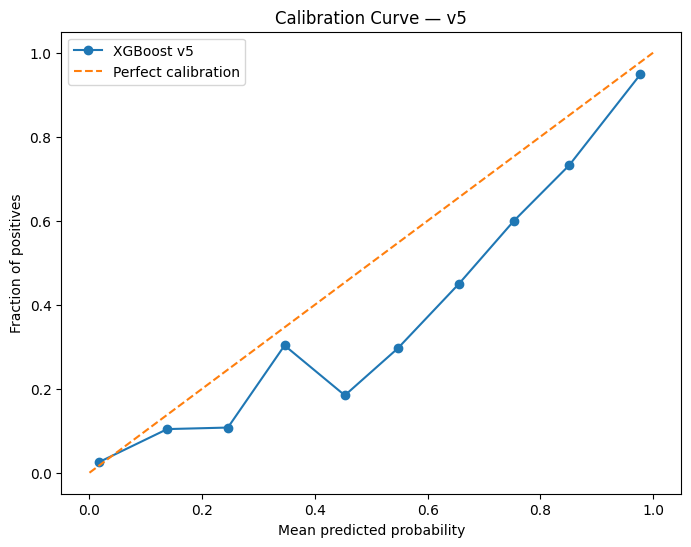

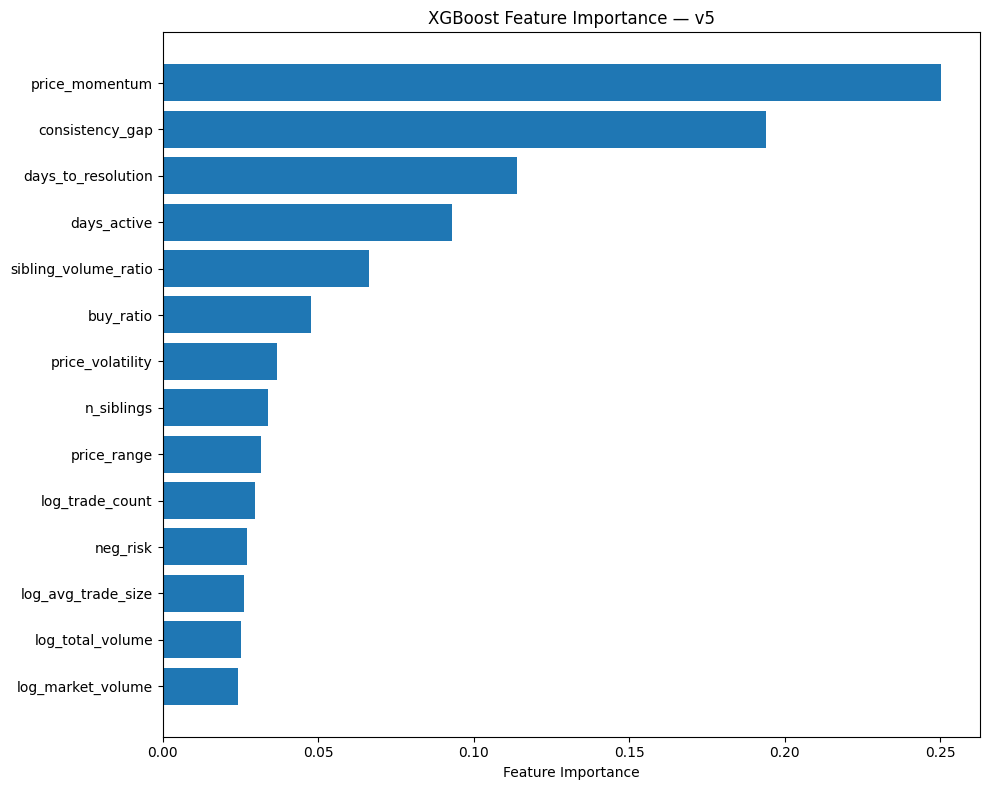

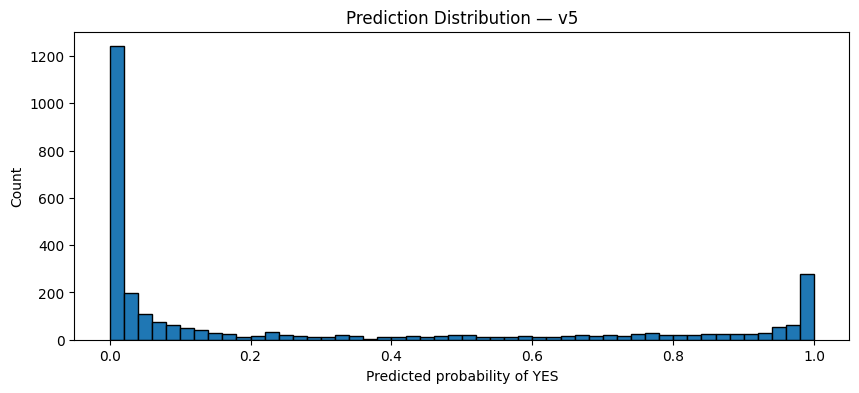

price_volatility: 0.3488
price_range: 0.3405
price_momentum: 0.5399
log_total_volume: 0.2709
log_trade_count: 0.1169
log_avg_trade_size: 0.3455
buy_ratio: 0.4953
log_market_volume: 0.1535
days_active: -0.1294
days_to_resolution: 0.1799
neg_risk: -0.3390
n_siblings: -0.2811
consistency_gap: 0.4249
sibling_volume_ratio: -0.3929


In [18]:
# Check 2 — Calibration curve
fraction_of_positives, mean_predicted_value = calibration_curve(
    y_test.to_numpy(), y_test_proba, n_bins=10
)

plt.figure(figsize=(8, 6))
plt.plot(mean_predicted_value, fraction_of_positives, marker='o', label='XGBoost v5')
plt.plot([0, 1], [0, 1], linestyle='--', label='Perfect calibration')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Calibration Curve — v5')
plt.legend()
plt.savefig('calibration_curve_v5.png')
plt.show()

# Check 3 — Feature importance
importance_df = pd.DataFrame({
    'feature': FEATURE_COLS,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(importance_df['feature'], importance_df['importance'])
plt.xlabel('Feature Importance')
plt.title('XGBoost Feature Importance — v5')
plt.tight_layout()
plt.savefig('feature_importance_v5.png')
plt.show()

# Check 4 — Prediction distribution
plt.figure(figsize=(10, 4))
plt.hist(y_test_proba, bins=50, edgecolor='black')
plt.xlabel('Predicted probability of YES')
plt.ylabel('Count')
plt.title('Prediction Distribution — v5')
plt.savefig('prediction_distribution_v5.png')
plt.show()

# Feature correlations
for col in FEATURE_COLS:
    corr = np.corrcoef(
        test[col].to_numpy(),
        y_test.to_numpy().ravel()
    )[0,1]
    print(f"{col}: {corr:.4f}")

In [1]:
import polars as pl

In [2]:
# Load test parquet with price_end
test = pl.read_parquet('data/model/test.parquet')

# Check distribution of price_end for disagreement cases
# You need to re-run backtest storing results_df first
# Then check price distribution on disagreements
print(test['price_end'].describe())

# How many markets have price_end far from 0.5?
strong_no  = test.filter(pl.col('price_end') < 0.3)
strong_yes = test.filter(pl.col('price_end') > 0.7)
uncertain  = test.filter(
    (pl.col('price_end') >= 0.3) & 
    (pl.col('price_end') <= 0.7)
)

print(f"Strong NO markets (price < 0.3):     {len(strong_no)}")
print(f"Strong YES markets (price > 0.7):    {len(strong_yes)}")
print(f"Uncertain markets (0.3-0.7):         {len(uncertain)}")

shape: (9, 2)
┌────────────┬──────────┐
│ statistic  ┆ value    │
│ ---        ┆ ---      │
│ str        ┆ f64      │
╞════════════╪══════════╡
│ count      ┆ 2889.0   │
│ null_count ┆ 0.0      │
│ mean       ┆ 0.269113 │
│ std        ┆ 0.379616 │
│ min        ┆ 0.001    │
│ 25%        ┆ 0.001    │
│ 50%        ┆ 0.022    │
│ 75%        ┆ 0.52     │
│ max        ┆ 0.999    │
└────────────┴──────────┘
Strong NO markets (price < 0.3):     2002
Strong YES markets (price > 0.7):    594
Uncertain markets (0.3-0.7):         293


In [3]:
# Load results from backtest
# Re-run conformal.py saving results_df first, or reconstruct here

test = pl.read_parquet('data/model/test.parquet')

# Bin price_end into ranges
test_with_bins = test.with_columns(
    pl.when(pl.col('price_end') < 0.1).then(pl.lit('0.0-0.1'))
    .when(pl.col('price_end') < 0.3).then(pl.lit('0.1-0.3'))
    .when(pl.col('price_end') < 0.5).then(pl.lit('0.3-0.5'))
    .when(pl.col('price_end') < 0.7).then(pl.lit('0.5-0.7'))
    .when(pl.col('price_end') < 0.9).then(pl.lit('0.7-0.9'))
    .otherwise(pl.lit('0.9-1.0'))
    .alias('price_bin')
)

print(test_with_bins.group_by('price_bin')
    .agg(pl.col('price_end').count().alias('count'))
    .sort('price_bin'))

shape: (6, 2)
┌───────────┬───────┐
│ price_bin ┆ count │
│ ---       ┆ ---   │
│ str       ┆ u32   │
╞═══════════╪═══════╡
│ 0.0-0.1   ┆ 1745  │
│ 0.1-0.3   ┆ 257   │
│ 0.3-0.5   ┆ 149   │
│ 0.5-0.7   ┆ 132   │
│ 0.7-0.9   ┆ 136   │
│ 0.9-1.0   ┆ 470   │
└───────────┴───────┘
